# 5 · Métodos modernos (deepod) y el techo estructural

### 5.1 — Comparación con AD tabular profundo moderno
Benchmark contra el estado del arte vía la librería `deepod`: DeepSVDD (one-class),
ICL (contrastive), NeuTraL/GOAD (transformation-based).

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

In [2]:
explib.show(explib.tbl_modern())

,modelo,soja_pr,maiz_pr,nota
0,VAE seed-ensemble (nuestro),0.592,0.508,SOTA
1,IForest (baseline),0.511,0.492,—
2,DeepSVDD,0.432,0.426,deep one-class
3,ICL,0.332,0.342,internal contrastive learning
4,NeuTraL,0.240,0.234,transformaciones; bajo azar
5,GOAD,NaN,NaN,impracticablemente lento


**Ninguno se acerca al VAE.** El mejor (DeepSVDD, 0.43) queda lejos del VAE
(0.592) e incluso debajo del IForest (0.51). El argumento del informe queda blindado:
probamos contra lo último y nuestro enfoque es mejor para *estos* datos.

### 5.2 — El techo estructural (por qué ningún modelo pasa de ~0.6)
Tres análisis independientes (en `analyze_errors.py`, `analyze_labels.py`,
`analyze_datamap.py`) muestran que el límite **no es del modelo**:
- **Cross-modelo:** ~68% de las anomalías las fallan TODOS los modelos, y esas tienen
  **clima normal** (sin firma de sequía). Si fuera la arquitectura, modelos distintos
  fallarían en muestras distintas; fallan en las mismas.
- **Auditoría de etiqueta:** excluir las anomalías sospechosas de ruido **no** mejora
  la PR-AUC → el techo no es etiqueta-basura, son anomalías genuinas.
- **Data map (Dataset Cartography):** las muestras "siempre mal reconstruidas" no
  coinciden con las anomalías de rinde → la dificultad es rareza climática, no rinde.

**Conclusión:** ~70% de las anomalías de rinde tienen causas **no climáticas**
(plaga, granizo, manejo, mercado) **invisibles a cualquier feature climática/satelital
disponible**. Es una propiedad del problema (features de clima ↔ etiqueta de rinde),
no una falla del modelo. Eso es un resultado fuerte y honesto para el informe.

### Mapa depto×campaña de errores por consenso (si `analyze_errors.py` ya generó el PNG)

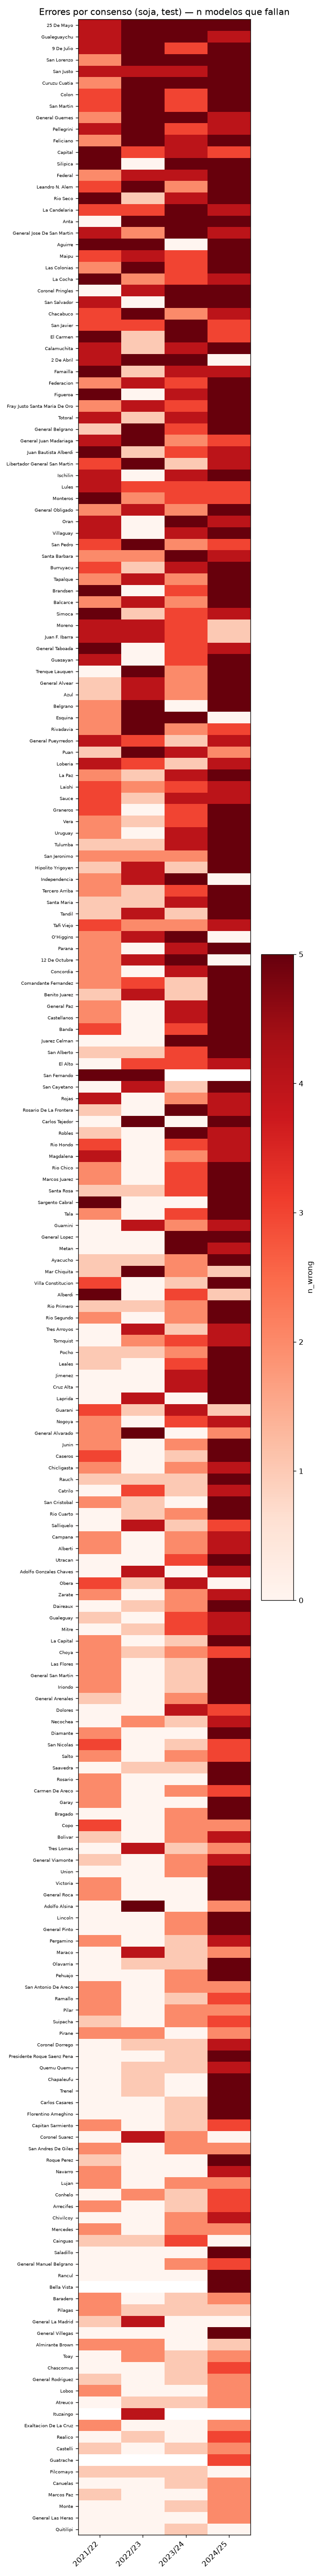

In [3]:
import os
from IPython.display import Image, display
p = os.path.join(explib.ROOT, "analysis", "consensus_heatmap_soja.png")
display(Image(p)) if os.path.exists(p) else print("Corré: python analyze_errors.py --cultivo soja")

## Comparación final de TODOS los modelos clave (con desvío estándar)
El cierre: PR-AUC media±std de los modelos principales, soja y maíz. Permite ver de
un vistazo **cuál es mejor y con cuánta confianza**.

In [4]:
explib.show(explib.tbl_leaderboard())

,model,desc,soja_pr,soja_std,maiz_pr,maiz_std
0,vae_seedens_v1 ⭐,VAE seed-ensemble (lat16),0.592,0.010,0.508,0.005
1,vae_seedens_deep,VAE seed-ensemble (deep),0.585,0.007,0.500,0.003
2,vae_v4 (single),VAE recon_prob single,0.559,0.035,0.479,0.070
3,vae_v15 (single),VAE recon_prob deep single,0.553,0.036,0.489,0.060
4,iforest_v2,Isolation Forest (mf=0.3),0.511,0.031,0.492,0.030


/Users/joaquin/Documents/facultad /ml/tp final/Trabajo_final_ML/experiments/explib.py:201: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(axis="x", alpha=0.3); fig.tight_layout(); return fig
/Users/joaquin/Documents/facultad /ml/tp final/Trabajo_final_ML/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


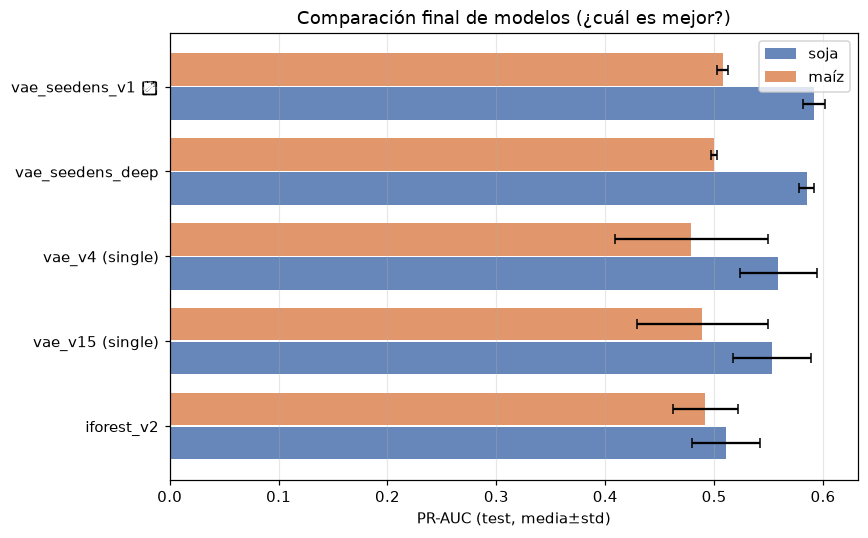

In [5]:
explib.plot_leaderboard_compare(); plt.show()

**El veredicto:** `vae_seedens_v1` (seed-ensemble del VAE `recon_prob`) es el
mejor en ambos cultivos, con el desvío más chico. Le sigue su variante deep. El
IForest es un baseline fuerte. Ni features satelitales, ni AE/DAE, ni métodos
modernos lo superaron — y el techo de ~0.6 es estructural (anomalías de rinde sin
firma climática), no del modelo.